# Calibración Estéreo y Estimación de Profundidad

**Cámara**: SVPRO stereo (side-by-side, 2560×800 px → dos mitades de 1280×800)  
**Tablero**: 10×7 cuadros → **9×6 esquinas interiores**, cuadro = 40.5 mm  
**NPZ de salida**: `stereo_calibration_result.npz`

| Sección | Descripción |
|---------|-------------|
| 1 | Calibración completa → guarda el NPZ |
| 2 | Carga el NPZ e imprime todos los parámetros |
| 3 | Selección y configuración del algoritmo de disparidad |
| 4 | Prueba estática: rectificación + mapa de profundidad |
| 5 | Cámara en vivo con profundidad calibrada (resolución completa) |
| 6 | Cámara en vivo con downsampling (~640 px por ojo, para el modelo) |

## 1. Calibración Estéreo
Lee las imágenes de `../data/new_new_cam_calibration_imgs/`, detecta el tablero en ambas mitades, calibra cada cámara individualmente y luego realiza la calibración estéreo. Guarda el resultado en `stereo_calibration_result.npz`.

  CALIBRACIÓN ESTÉREO
  Imágenes    : 26 encontradas
  Tablero     : 9x6 esquinas interiores (tablero 10x7 cuadros)
  Cuadro real : 40.5 mm

  [ 1] photo_1.jpeg               izq=False  der=True   ✗
  [ 2] photo_10.jpeg              izq=True   der=True   ✓
  [ 3] photo_11.jpeg              izq=True   der=True   ✓
  [ 4] photo_12.jpeg              izq=True   der=True   ✓
  [ 5] photo_13.jpeg              izq=True   der=True   ✓
  [ 6] photo_14.jpeg              izq=True   der=True   ✓
  [ 7] photo_15.jpeg              izq=True   der=True   ✓
  [ 8] photo_16.jpeg              izq=True   der=True   ✓
  [ 9] photo_17.jpeg              izq=True   der=True   ✓
  [10] photo_18.jpeg              izq=True   der=True   ✓
  [11] photo_19.jpeg              izq=True   der=True   ✓
  [12] photo_2.jpeg               izq=False  der=True   ✗
  [13] photo_20.jpeg              izq=True   der=True   ✓
  [14] photo_21.jpeg              izq=True   der=True   ✓
  [15] photo_22.jpeg              izq=True   de

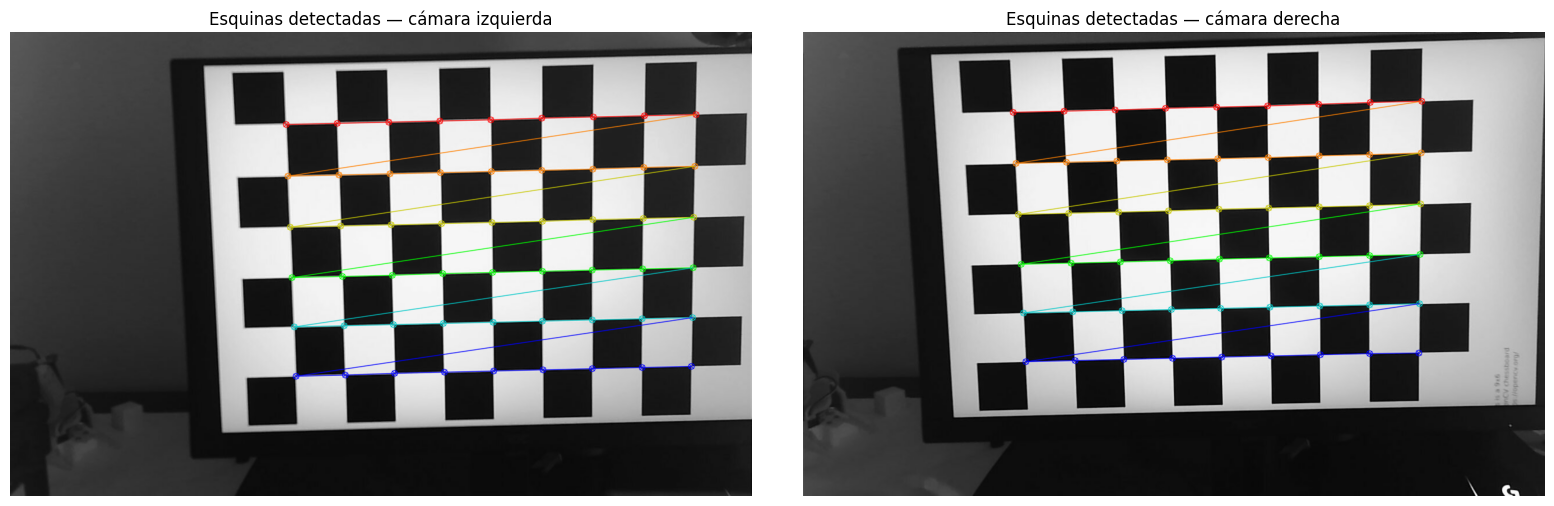


  CALIBRACIÓN INDIVIDUAL
  Cámara izquierda  RMS=0.1008 px
  Cámara derecha    RMS=0.0976 px

  CALIBRACIÓN ESTÉREO
  RMS estéreo  : 1.0324 px
  Baseline     : 59.22 mm  (5.92 cm)
  Rotación R   :
[[ 9.99896060e-01 -4.40373555e-04  1.44109137e-02]
 [ 5.09060711e-04  9.99988527e-01 -4.76300800e-03]
 [-1.44086509e-02  4.76984896e-03  9.99884813e-01]]
  Traslación T : [-59.20092129  -1.39238313   0.55450181]

  Guardado en: stereo_calibration_result.npz


In [21]:
import cv2
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

# ── Parámetros ────────────────────────────────────────────────────
IMGS_DIR        = "../data/new_new_cam_calibration_imgs"
OUTPUT_FILE     = "stereo_calibration_result.npz"
CHESSBOARD_COLS = 9       # esquinas interiores = columnas_cuadros - 1
CHESSBOARD_ROWS = 6       # esquinas interiores = filas_cuadros   - 1
SQUARE_SIZE_MM  = 40.5

# ── Puntos 3D del tablero (z=0) ───────────────────────────────────
board_size = (CHESSBOARD_COLS, CHESSBOARD_ROWS)
objp = np.zeros((CHESSBOARD_COLS * CHESSBOARD_ROWS, 3), np.float32)
objp[:, :2] = np.mgrid[0:CHESSBOARD_COLS, 0:CHESSBOARD_ROWS].T.reshape(-1, 2)
objp *= SQUARE_SIZE_MM

criteria_sub    = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-5)
criteria_stereo = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 200, 1e-7)

image_paths = sorted(
    glob.glob(os.path.join(IMGS_DIR, "*.jpeg")) +
    glob.glob(os.path.join(IMGS_DIR, "*.jpg"))
)

print(f"{'='*60}")
print(f"  CALIBRACIÓN ESTÉREO")
print(f"{'='*60}")
print(f"  Imágenes    : {len(image_paths)} encontradas")
print(f"  Tablero     : {CHESSBOARD_COLS}x{CHESSBOARD_ROWS} esquinas interiores (tablero {CHESSBOARD_COLS+1}x{CHESSBOARD_ROWS+1} cuadros)")
print(f"  Cuadro real : {SQUARE_SIZE_MM} mm")
print(f"{'='*60}\n")

obj_points, pts_left, pts_right = [], [], []
img_size     = None
ok_count     = 0
preview_data = None

for i, path in enumerate(image_paths):
    fname  = os.path.basename(path)
    img    = cv2.imread(path)
    mid    = img.shape[1] // 2
    gray_l = cv2.cvtColor(img[:, :mid], cv2.COLOR_BGR2GRAY)
    gray_r = cv2.cvtColor(img[:, mid:], cv2.COLOR_BGR2GRAY)

    if img_size is None:
        img_size = gray_l.shape[::-1]   # (width, height)

    fl, cl = cv2.findChessboardCorners(gray_l, board_size)
    fr, cr = cv2.findChessboardCorners(gray_r, board_size)

    if fl:
        cl = cv2.cornerSubPix(gray_l, cl, (11, 11), (-1, -1), criteria_sub)
    if fr:
        cr = cv2.cornerSubPix(gray_r, cr, (11, 11), (-1, -1), criteria_sub)

    mark = "✓" if (fl and fr) else "✗"
    print(f"  [{i+1:>2}] {fname:<25}  izq={str(fl):<5}  der={str(fr):<5}  {mark}")

    if fl and fr:
        obj_points.append(objp)
        pts_left.append(cl)
        pts_right.append(cr)
        ok_count += 1
        if preview_data is None:
            preview_data = (img[:, :mid].copy(), img[:, mid:].copy(), cl, cr)

print(f"\n  Válidas: {ok_count} / {len(image_paths)}")

# ── Visualizar detección de esquinas en la primera imagen válida ──
if preview_data is not None:
    lc, rc, cl, cr = preview_data
    vis_l = cv2.drawChessboardCorners(lc.copy(), board_size, cl, True)
    vis_r = cv2.drawChessboardCorners(rc.copy(), board_size, cr, True)
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    ax[0].imshow(cv2.cvtColor(vis_l, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Esquinas detectadas — cámara izquierda"); ax[0].axis("off")
    ax[1].imshow(cv2.cvtColor(vis_r, cv2.COLOR_BGR2RGB))
    ax[1].set_title("Esquinas detectadas — cámara derecha");   ax[1].axis("off")
    plt.tight_layout(); plt.show()

# ── Calibración individual ────────────────────────────────────────
print(f"\n{'='*60}")
print("  CALIBRACIÓN INDIVIDUAL")
print(f"{'='*60}")
rms_l, K_l, D_l, _, _ = cv2.calibrateCamera(obj_points, pts_left,  img_size, None, None)
rms_r, K_r, D_r, _, _ = cv2.calibrateCamera(obj_points, pts_right, img_size, None, None)
print(f"  Cámara izquierda  RMS={rms_l:.4f} px")
print(f"  Cámara derecha    RMS={rms_r:.4f} px")

# ── Calibración estéreo ───────────────────────────────────────────
print(f"\n{'='*60}")
print("  CALIBRACIÓN ESTÉREO")
print(f"{'='*60}")
rms_s, K_l, D_l, K_r, D_r, R, T, E, F = cv2.stereoCalibrate(
    obj_points, pts_left, pts_right,
    K_l, D_l, K_r, D_r, img_size,
    criteria=criteria_stereo,
    flags=cv2.CALIB_FIX_INTRINSIC
)
print(f"  RMS estéreo  : {rms_s:.4f} px")
print(f"  Baseline     : {np.linalg.norm(T):.2f} mm  ({np.linalg.norm(T)/10:.2f} cm)")
print(f"  Rotación R   :\n{R}")
print(f"  Traslación T : {T.ravel()}")

# ── Rectificación ─────────────────────────────────────────────────
R1, R2, P1, P2, Q, roi_l, roi_r = cv2.stereoRectify(
    K_l, D_l, K_r, D_r, img_size, R, T, alpha=0)

# ── Guardar ───────────────────────────────────────────────────────
np.savez(OUTPUT_FILE,
         K_l=K_l, D_l=D_l, K_r=K_r, D_r=D_r,
         R=R, T=T, E=E, F=F,
         R1=R1, R2=R2, P1=P1, P2=P2, Q=Q,
         roi_l=roi_l, roi_r=roi_r,
         img_size=np.array(img_size),
         rms_stereo=rms_s)
print(f"\n  Guardado en: {OUTPUT_FILE}")

## 2. Cargar y verificar calibración
Carga `stereo_calibration_result.npz` e imprime todos los parámetros. Las variables quedan disponibles para las siguientes secciones.

In [22]:
import numpy as np

NPZ_FILE = "stereo_calibration_result.npz"
_d = np.load(NPZ_FILE)

K_l      = _d['K_l'];    D_l      = _d['D_l']
K_r      = _d['K_r'];    D_r      = _d['D_r']
R        = _d['R'];      T        = _d['T']
R1       = _d['R1'];     R2       = _d['R2']
P1       = _d['P1'];     P2       = _d['P2']
Q        = _d['Q']
roi_l    = tuple(_d['roi_l'].tolist())
roi_r    = tuple(_d['roi_r'].tolist())
img_size = tuple(_d['img_size'].tolist())
rms_s    = float(_d['rms_stereo'])
baseline = float(np.linalg.norm(T))
fx       = float(K_l[0, 0])
fy       = float(K_l[1, 1])

fov_h = 2 * np.degrees(np.arctan(img_size[0] / (2 * fx)))
fov_v = 2 * np.degrees(np.arctan(img_size[1] / (2 * fy)))

print(f"{'='*60}")
print(f"  PARÁMETROS CARGADOS: {NPZ_FILE}")
print(f"{'='*60}")
print(f"  RMS estéreo  : {rms_s:.4f} px  (< 1.0 = bueno)")
print(f"  Baseline     : {baseline:.2f} mm  ({baseline/10:.2f} cm)")
print(f"  Resolución   : {img_size[0]}x{img_size[1]} px")
print(f"  Focal izq    : fx={fx:.2f}  fy={fy:.2f}  px")
print(f"  FOV          : {fov_h:.1f}° horiz  x  {fov_v:.1f}° vert")
print(f"\n  K_l (intrínseca izquierda):\n{K_l}")
print(f"\n  D_l (distorsión izquierda): {D_l.ravel()}")
print(f"\n  K_r (intrínseca derecha):\n{K_r}")
print(f"\n  D_r (distorsión derecha): {D_r.ravel()}")
print(f"\n  R  (rotación entre cámaras):\n{R}")
print(f"\n  T  (traslación, mm): {T.ravel()}")
print(f"\n  Q  (disparidad → 3D):\n{Q}")
print(f"\n  P1 (proyección izquierda):\n{P1}")
print(f"\n  P2 (proyección derecha):\n{P2}")
print(f"\n  ROI válida izq : {roi_l}")
print(f"  ROI válida der : {roi_r}")

  PARÁMETROS CARGADOS: stereo_calibration_result.npz
  RMS estéreo  : 1.0324 px  (< 1.0 = bueno)
  Baseline     : 59.22 mm  (5.92 cm)
  Resolución   : 1280x800 px
  Focal izq    : fx=1055.56  fy=1055.94  px
  FOV          : 62.5° horiz  x  41.5° vert

  K_l (intrínseca izquierda):
[[1.05556463e+03 0.00000000e+00 6.69785829e+02]
 [0.00000000e+00 1.05593912e+03 4.12759558e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

  D_l (distorsión izquierda): [ 0.01955615  0.05811663 -0.00058028 -0.00055226 -0.18238763]

  K_r (intrínseca derecha):
[[1.04763893e+03 0.00000000e+00 6.68790925e+02]
 [0.00000000e+00 1.04757689e+03 3.98021836e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

  D_r (distorsión derecha): [ 0.04118013 -0.06176631 -0.00012742 -0.00011717  0.03794631]

  R  (rotación entre cámaras):
[[ 9.99896060e-01 -4.40373555e-04  1.44109137e-02]
 [ 5.09060711e-04  9.99988527e-01 -4.76300800e-03]
 [-1.44086509e-02  4.76984896e-03  9.99884813e-01]]

  T  (traslación, mm): [-59.

## 3. Selección del algoritmo de disparidad

Cambia `STEREO_ALGO` para elegir el algoritmo antes de ejecutar las secciones 4 y 5:

| Valor | Algoritmo | Velocidad | Calidad | Notas |
|-------|-----------|-----------|---------|-------|
| `'bm'` | StereoBM | Muy rápido | Básica | Mejor en escenas con mucha textura |
| `'sgbm'` | StereoSGBM | Medio | Buena | Equilibrio calidad/velocidad |
| `'sgbm_wls'` | SGBM + filtro WLS | Lento | Excelente | Requiere `opencv-contrib` |

In [23]:
import cv2
import numpy as np

# ── CAMBIAR AQUI el algoritmo ─────────────────────────────────────
#   'bm'        → StereoBM          (más rápido, menos preciso)
#   'sgbm'      → StereoSGBM        (equilibrio calidad/velocidad)
#   'sgbm_wls'  → SGBM + filtro WLS (mejor calidad, requiere opencv-contrib)
STEREO_ALGO = 'sgbm_wls'

# ── Parámetros comunes ────────────────────────────────────────────
NUM_DISPARITIES = 96   # múltiplo de 16; aumentar para objetos cercanos
BLOCK_SIZE      = 5    # tamaño de bloque (impar); mayor = más suave, menos detalle


def create_stereo_matcher(algo):
    """Devuelve (matcher, wls_data). wls_data es None si no se usa WLS."""
    win = BLOCK_SIZE
    nd  = NUM_DISPARITIES

    if algo == 'bm':
        # StereoBM: rápido, trabaja bien con escenas texturizadas
        bm = cv2.StereoBM_create(numDisparities=nd, blockSize=max(win, 5) | 1)
        return bm, None

    elif algo == 'sgbm':
        # StereoSGBM: mejor manejo de áreas uniformes y bordes
        sgbm = cv2.StereoSGBM_create(
            minDisparity=0,
            numDisparities=nd,
            blockSize=win,
            P1=8  * 3 * win**2,
            P2=32 * 3 * win**2,
            disp12MaxDiff=1,
            uniquenessRatio=10,
            speckleWindowSize=100,
            speckleRange=32
        )
        return sgbm, None

    elif algo == 'sgbm_wls':
        # SGBM + filtro WLS: suaviza el mapa y rellena huecos usando consistencia L-R
        # Requiere opencv-contrib: pip install opencv-contrib-python
        try:
            left_m = cv2.StereoSGBM_create(
                minDisparity=0,
                numDisparities=nd,
                blockSize=win,
                P1=8  * 3 * win**2,
                P2=32 * 3 * win**2,
                disp12MaxDiff=1,
                uniquenessRatio=10,
                speckleWindowSize=100,
                speckleRange=32,
                mode=cv2.StereoSGBM_MODE_SGBM_3WAY
            )
            right_m    = cv2.ximgproc.createRightMatcher(left_m)
            wls_filter = cv2.ximgproc.createDisparityWLSFilter(left_m)
            wls_filter.setLambda(8000)
            wls_filter.setSigmaColor(1.5)
            return left_m, (right_m, wls_filter)
        except AttributeError:
            print("[!] opencv-contrib no disponible — usando 'sgbm' en su lugar")
            print("    Instala con: pip install opencv-contrib-python")
            return create_stereo_matcher('sgbm')

    else:
        raise ValueError(f"Algoritmo '{algo}' desconocido. Usa 'bm', 'sgbm' o 'sgbm_wls'")


def compute_disparity(gray_l, gray_r, matcher, wls_data=None):
    """Calcula el mapa de disparidad (float32, unidades reales)."""
    if wls_data is not None:
        right_m, wls_filter = wls_data
        disp_l = matcher.compute(gray_l, gray_r).astype(np.float32) / 16.0
        disp_r = right_m.compute(gray_r, gray_l).astype(np.float32) / 16.0
        return wls_filter.filter(disp_l, gray_l, None, disp_r).astype(np.float32)
    return matcher.compute(gray_l, gray_r).astype(np.float32) / 16.0


# Crear el matcher con los parámetros actuales
matcher, wls_data = create_stereo_matcher(STEREO_ALGO)

print(f"Algoritmo activo : '{STEREO_ALGO}'")
print(f"numDisparities   : {NUM_DISPARITIES}")
print(f"blockSize        : {BLOCK_SIZE}")
print(f"Filtro WLS       : {'si' if wls_data else 'no'}")

Algoritmo activo : 'sgbm_wls'
numDisparities   : 96
blockSize        : 5
Filtro WLS       : si


## 4. Prueba estática: rectificación y mapa de profundidad
Carga una imagen de calibración, aplica los mapas de rectificación y calcula el mapa de disparidad/profundidad con el algoritmo seleccionado.

Mapas calculados para 1280x800 px


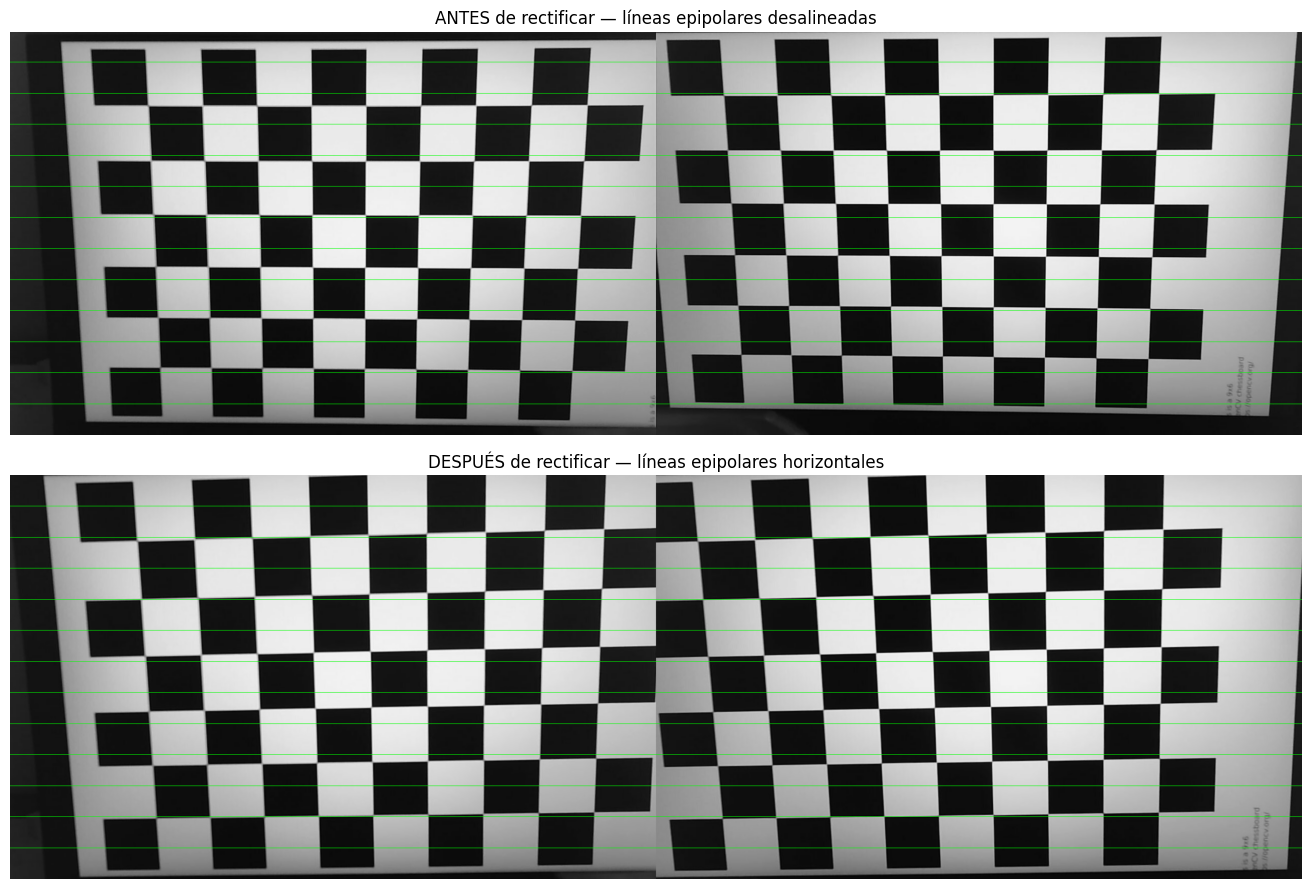

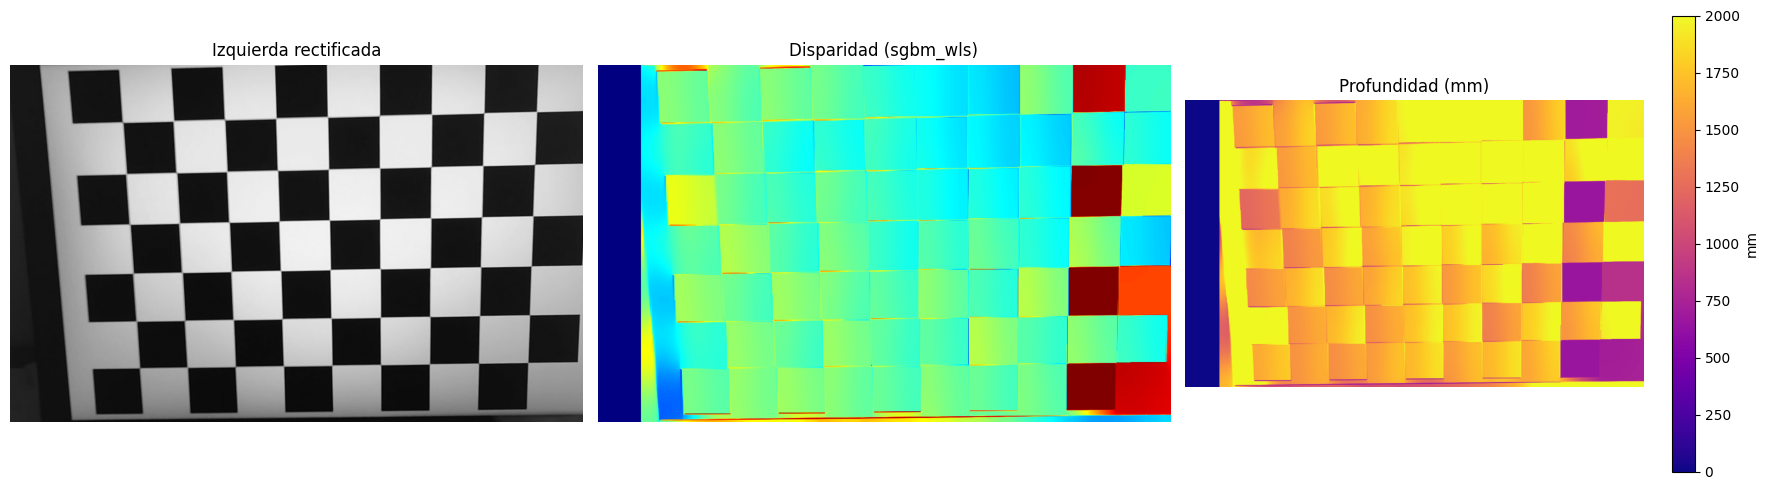

Algoritmo: sgbm_wls
Profundidad  →  min: 658 mm  |  max: 2381906 mm  |  media: 1928 mm


In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── Cargar calibración (por si se ejecuta esta celda sola) ────────
try:
    K_l
except NameError:
    _d       = np.load("stereo_calibration_result.npz")
    K_l, D_l = _d['K_l'], _d['D_l']
    K_r, D_r = _d['K_r'], _d['D_r']
    R1, R2   = _d['R1'],  _d['R2']
    P1, P2   = _d['P1'],  _d['P2']
    T        = _d['T']
    img_size = tuple(_d['img_size'].tolist())
    baseline = float(np.linalg.norm(T))
    fx       = float(K_l[0, 0])

# ── Reconstruir matcher si la sección 3 no se ejecutó ────────────
try:
    matcher
except NameError:
    STEREO_ALGO = 'sgbm'
    NUM_DISPARITIES = 96
    BLOCK_SIZE      = 5
    # (pega aquí create_stereo_matcher si ejecutas esta celda sola,
    #  o simplemente ejecuta la sección 3 primero)
    raise RuntimeError("Ejecuta primero la sección 3 para crear el matcher.")

# ── Calcular mapas de rectificación ───────────────────────────────
map_lx, map_ly = cv2.initUndistortRectifyMap(K_l, D_l, R1, P1, img_size, cv2.CV_32FC1)
map_rx, map_ry = cv2.initUndistortRectifyMap(K_r, D_r, R2, P2, img_size, cv2.CV_32FC1)
print(f"Mapas calculados para {img_size[0]}x{img_size[1]} px")

# ── Cargar imagen de prueba ───────────────────────────────────────
TEST_IMG = "../data/new_new_cam_calibration_imgs/photo_3.jpeg"
img = cv2.imread(TEST_IMG)
mid = img.shape[1] // 2

left_rect  = cv2.remap(img[:, :mid], map_lx, map_ly, cv2.INTER_LINEAR)
right_rect = cv2.remap(img[:, mid:], map_rx, map_ry, cv2.INTER_LINEAR)

# ── Líneas epipolares para verificar rectificación ────────────────
def add_epipolar_lines(image, n=12):
    out = image.copy()
    for i in range(1, n + 1):
        y = int(i * out.shape[0] / (n + 1))
        cv2.line(out, (0, y), (out.shape[1], y), (0, 255, 0), 1)
    return out

before = add_epipolar_lines(np.hstack([img[:, :mid], img[:, mid:]]))
after  = add_epipolar_lines(np.hstack([left_rect,    right_rect]))

fig, ax = plt.subplots(2, 1, figsize=(16, 9))
ax[0].imshow(cv2.cvtColor(before, cv2.COLOR_BGR2RGB))
ax[0].set_title("ANTES de rectificar — líneas epipolares desalineadas"); ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(after, cv2.COLOR_BGR2RGB))
ax[1].set_title("DESPUÉS de rectificar — líneas epipolares horizontales"); ax[1].axis("off")
plt.tight_layout(); plt.show()

# ── Disparidad y profundidad ──────────────────────────────────────
gray_l = cv2.cvtColor(left_rect,  cv2.COLOR_BGR2GRAY)
gray_r = cv2.cvtColor(right_rect, cv2.COLOR_BGR2GRAY)
disp   = compute_disparity(gray_l, gray_r, matcher, wls_data)

# depth = (fx * baseline) / disparity
valid     = disp > 0
depth_map = np.where(valid, (fx * baseline) / np.where(valid, disp, 1), 0)

disp_color = cv2.applyColorMap(
    cv2.normalize(disp, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U),
    cv2.COLORMAP_JET
)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].imshow(cv2.cvtColor(left_rect, cv2.COLOR_BGR2RGB))
ax[0].set_title("Izquierda rectificada"); ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(disp_color, cv2.COLOR_BGR2RGB))
ax[1].set_title(f"Disparidad ({STEREO_ALGO})"); ax[1].axis("off")
im = ax[2].imshow(depth_map, cmap="plasma", vmin=0, vmax=2000)
ax[2].set_title("Profundidad (mm)"); ax[2].axis("off")
plt.colorbar(im, ax=ax[2], label="mm")
plt.tight_layout(); plt.show()

if valid.any():
    d = depth_map[valid]
    print(f"Algoritmo: {STEREO_ALGO}")
    print(f"Profundidad  →  min: {d.min():.0f} mm  |  max: {d.max():.0f} mm  |  media: {d.mean():.0f} mm")

## 5. Cámara en vivo con profundidad calibrada
Abre la cámara, aplica la rectificación y el algoritmo seleccionado en tiempo real.  
Pulsa **`q`** para salir.

In [25]:
import cv2
import numpy as np

# ── Configuración ─────────────────────────────────────────────────
ID_CAMARA = 2
NPZ_FILE  = "stereo_calibration_result.npz"

# ── Cargar calibración ────────────────────────────────────────────
_d       = np.load(NPZ_FILE)
K_l, D_l = _d['K_l'], _d['D_l']
K_r, D_r = _d['K_r'], _d['D_r']
R1, R2   = _d['R1'],  _d['R2']
P1, P2   = _d['P1'],  _d['P2']
T        = _d['T']
img_size = tuple(_d['img_size'].tolist())
baseline = float(np.linalg.norm(T))
fx       = float(K_l[0, 0])

# ── Verificar que el matcher está creado (sección 3) ─────────────
try:
    matcher
except NameError:
    raise RuntimeError("Ejecuta primero la sección 3 para crear el matcher.")

# ── Mapas de rectificación (calculados una sola vez) ──────────────
map_lx, map_ly = cv2.initUndistortRectifyMap(K_l, D_l, R1, P1, img_size, cv2.CV_32FC1)
map_rx, map_ry = cv2.initUndistortRectifyMap(K_r, D_r, R2, P2, img_size, cv2.CV_32FC1)

# ── Abrir cámara ──────────────────────────────────────────────────
cap = cv2.VideoCapture(ID_CAMARA, cv2.CAP_V4L2)
cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*'MJPG'))
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  2560)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT,  800)

real_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
real_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"Cámara abierta — resolución real: {real_w}x{real_h}")
print(f"Algoritmo activo: {STEREO_ALGO}")
print("Pulsa 'q' para cerrar")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            continue

        mid     = frame.shape[1] // 2
        left_r  = cv2.remap(frame[:, :mid], map_lx, map_ly, cv2.INTER_LINEAR)
        right_r = cv2.remap(frame[:, mid:], map_rx, map_ry, cv2.INTER_LINEAR)

        gray_l = cv2.cvtColor(left_r,  cv2.COLOR_BGR2GRAY)
        gray_r = cv2.cvtColor(right_r, cv2.COLOR_BGR2GRAY)

        disp = compute_disparity(gray_l, gray_r, matcher, wls_data)

        # Profundidad en el píxel central
        cy, cx   = disp.shape[0] // 2, disp.shape[1] // 2
        d_center = float(disp[cy, cx])
        if d_center > 0:
            depth_mm  = (fx * baseline) / d_center
            depth_txt = f"{STEREO_ALGO} | Centro: {depth_mm:.0f} mm  ({depth_mm/1000:.2f} m)"
        else:
            depth_txt = f"{STEREO_ALGO} | Centro: sin dato"

        disp_vis   = cv2.normalize(disp, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
        disp_color = cv2.applyColorMap(disp_vis, cv2.COLORMAP_JET)
        cv2.putText(disp_color, depth_txt, (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        cv2.circle(disp_color, (cx, cy), 6, (255, 255, 255), -1)

        cv2.imshow("Camara izquierda (rectificada)", left_r)
        cv2.imshow("Mapa de profundidad",            disp_color)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
finally:
    cap.release()
    cv2.destroyAllWindows()
    print("Cerrado.")

Cámara abierta — resolución real: 2560x800
Algoritmo activo: sgbm_wls
Pulsa 'q' para cerrar
Cerrado.


## 6. Cámara en vivo con downsampling (~640 px por ojo)

Resoluciones nativas disponibles en la cámara (`/dev/video2`, MJPG):

| Resolución total | Por ojo | FPS máx |
|-----------------|---------|---------|
| 2560×800 | 1280×800 | 120 |
| 1280×480 | **640×240** | 120 |
| 640×240 | 320×120 | 210 |

Dos modos de downsampling seleccionables con `DOWNSAMPLE_MODE`:

| Modo | Cómo funciona | Ventaja | Inconveniente |
|------|--------------|---------|---------------|
| `'software'` | Captura 2560×800, escala K×0.5, remapea a **640×400** | Calibración exacta (mismo campo de visión) | Transfiere el frame completo por USB |
| `'native'` | Pide 1280×480 al driver → **640×240** por ojo | Menor ancho de banda USB, máximo FPS | El sensor puede usar un crop diferente; la calibración es aproximada |

Requiere haber ejecutado la **sección 3** (`matcher`, `wls_data`, `STEREO_ALGO`, `NUM_DISPARITIES`).

In [30]:
import cv2
import numpy as np

# ── PARÁMETROS — sólo hay que tocar esta sección ──────────────────
ID_CAMARA = 2

# Modo de downsampling:
#   'software' → captura 2560×800 y escala por software (calibración exacta)
#   'native'   → pide 1280×480 al driver, 640×240 por ojo (calibración aprox.)
DOWNSAMPLE_MODE = 'software'

# Ancho objetivo por ojo (sólo para modo 'software')
# El alto se calcula proporcionalmente: 640 → alto = 400 (mantiene ratio 1280×800)
TARGET_WIDTH = 640

NPZ_FILE = "stereo_calibration_result.npz"

# ── Verificar que el matcher está creado (sección 3) ─────────────
try:
    matcher
except NameError:
    raise RuntimeError("Ejecuta primero la sección 3 para crear el matcher.")

# ── Cargar calibración base (1280×800) ────────────────────────────
_d        = np.load(NPZ_FILE)
K_l_full  = _d['K_l'].copy();  D_l = _d['D_l']
K_r_full  = _d['K_r'].copy();  D_r = _d['D_r']
R         = _d['R'];            T   = _d['T']
baseline  = float(np.linalg.norm(T))
calib_w, calib_h = int(_d['img_size'][0]), int(_d['img_size'][1])   # 1280, 800

# ── Calcular resolución y matrices escaladas ──────────────────────
if DOWNSAMPLE_MODE == 'software':
    target_h  = int(calib_h * TARGET_WIDTH / calib_w)   # 400
    target_sz = (TARGET_WIDTH, target_h)
    scale     = TARGET_WIDTH / calib_w                   # 0.5

    # Escalar K proporcionalmente (distorsión D no cambia con la resolución)
    K_l = K_l_full.copy()
    K_l[0, 0] *= scale;  K_l[0, 2] *= scale   # fx, cx
    K_l[1, 1] *= scale;  K_l[1, 2] *= scale   # fy, cy
    K_r = K_r_full.copy()
    K_r[0, 0] *= scale;  K_r[0, 2] *= scale
    K_r[1, 1] *= scale;  K_r[1, 2] *= scale

    cap_w, cap_h = 2560, 800
    print(f"Modo software : captura {cap_w}x{cap_h}  ->  por ojo {target_sz[0]}x{target_sz[1]}  (escala {scale:.2f})")

else:  # 'native'
    target_sz = (640, 240)
    sx = 640 / calib_w   # 0.5
    sy = 240 / calib_h   # 0.3  (sensor crop diferente en vertical)

    K_l = K_l_full.copy()
    K_l[0, 0] *= sx;  K_l[0, 2] *= sx
    K_l[1, 1] *= sy;  K_l[1, 2] *= sy
    K_r = K_r_full.copy()
    K_r[0, 0] *= sx;  K_r[0, 2] *= sx
    K_r[1, 1] *= sy;  K_r[1, 2] *= sy

    scale    = sx
    cap_w, cap_h = 1280, 480
    print(f"Modo native   : captura {cap_w}x{cap_h}  ->  por ojo {target_sz[0]}x{target_sz[1]}")
    print("  Nota: recalibra con imagenes a esta resolucion para maxima precision.")

# numDisparities escalado (multiplo de 16, minimo 16)
nd_small = max(16, round(NUM_DISPARITIES * scale / 16) * 16)
fx_small = float(K_l[0, 0])
print(f"numDisparities (escalado) : {nd_small}  (original {NUM_DISPARITIES})")

# ── Rectificación a la resolución objetivo ────────────────────────
R1s, R2s, P1s, P2s, _, _, _ = cv2.stereoRectify(
    K_l, D_l, K_r, D_r, target_sz, R, T, alpha=0)

map_lx, map_ly = cv2.initUndistortRectifyMap(K_l, D_l, R1s, P1s, target_sz, cv2.CV_32FC1)
map_rx, map_ry = cv2.initUndistortRectifyMap(K_r, D_r, R2s, P2s, target_sz, cv2.CV_32FC1)
print(f"Mapas de rectificacion calculados para {target_sz[0]}x{target_sz[1]} px")

# ── Crear matcher con numDisparities escalado ─────────────────────
win_s = BLOCK_SIZE
if STEREO_ALGO == 'bm':
    matcher_s = cv2.StereoBM_create(numDisparities=nd_small, blockSize=max(win_s, 5) | 1)
    wls_s     = None
elif STEREO_ALGO == 'sgbm':
    matcher_s = cv2.StereoSGBM_create(
        minDisparity=0, numDisparities=nd_small, blockSize=win_s,
        P1=8*3*win_s**2, P2=32*3*win_s**2,
        disp12MaxDiff=1, uniquenessRatio=10,
        speckleWindowSize=100, speckleRange=32)
    wls_s = None
else:  # sgbm_wls
    try:
        _lm = cv2.StereoSGBM_create(
            minDisparity=0, numDisparities=nd_small, blockSize=win_s,
            P1=8*3*win_s**2, P2=32*3*win_s**2,
            disp12MaxDiff=1, uniquenessRatio=10,
            speckleWindowSize=100, speckleRange=32,
            mode=cv2.StereoSGBM_MODE_SGBM_3WAY)
        _rm  = cv2.ximgproc.createRightMatcher(_lm)
        _wls = cv2.ximgproc.createDisparityWLSFilter(_lm)
        _wls.setLambda(8000);  _wls.setSigmaColor(1.5)
        matcher_s, wls_s = _lm, (_rm, _wls)
    except AttributeError:
        matcher_s = cv2.StereoSGBM_create(
            minDisparity=0, numDisparities=nd_small, blockSize=win_s,
            P1=8*3*win_s**2, P2=32*3*win_s**2)
        wls_s = None
        print("[!] WLS no disponible, usando SGBM sin filtro")

# ── Abrir cámara ──────────────────────────────────────────────────
cap = cv2.VideoCapture(ID_CAMARA, cv2.CAP_V4L2)
cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*'MJPG'))
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  cap_w)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, cap_h)

real_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
real_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"\nCamara abierta : {real_w}x{real_h}  ->  salida por ojo: {target_sz[0]}x{target_sz[1]}")
print(f"Algoritmo      : {STEREO_ALGO} | Modo: {DOWNSAMPLE_MODE}")
print("Pulsa 'q' para salir")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            continue

        mid   = frame.shape[1] // 2
        raw_l = frame[:, :mid]
        raw_r = frame[:, mid:]

        # En modo software: redimensionar antes del remap (mas eficiente)
        if DOWNSAMPLE_MODE == 'software':
            raw_l = cv2.resize(raw_l, target_sz, interpolation=cv2.INTER_AREA)
            raw_r = cv2.resize(raw_r, target_sz, interpolation=cv2.INTER_AREA)

        left_r  = cv2.remap(raw_l, map_lx, map_ly, cv2.INTER_LINEAR)
        right_r = cv2.remap(raw_r, map_rx, map_ry, cv2.INTER_LINEAR)

        gray_l = cv2.cvtColor(left_r,  cv2.COLOR_BGR2GRAY)
        gray_r = cv2.cvtColor(right_r, cv2.COLOR_BGR2GRAY)

        disp = compute_disparity(gray_l, gray_r, matcher_s, wls_s)

        cy, cx   = disp.shape[0] // 2, disp.shape[1] // 2
        d_center = float(disp[cy, cx])
        if d_center > 0:
            depth_mm  = (fx_small * baseline) / d_center
            depth_txt = f"{STEREO_ALGO}|{target_sz[0]}px  {depth_mm:.0f}mm ({depth_mm/1000:.2f}m)"
        else:
            depth_txt = f"{STEREO_ALGO}|{target_sz[0]}px  sin dato"

        disp_vis   = cv2.normalize(disp, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
        disp_color = cv2.applyColorMap(disp_vis, cv2.COLORMAP_JET)
        cv2.putText(disp_color, depth_txt, (8, 22),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        cv2.circle(disp_color, (cx, cy), 5, (255, 255, 255), -1)

        cv2.imshow(f"Ojo izq ({target_sz[0]}x{target_sz[1]})", left_r)
        cv2.imshow("Profundidad downsampled",                    disp_color)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
finally:
    cap.release()
    cv2.destroyAllWindows()
    print("Cerrado.")

Modo software : captura 2560x800  ->  por ojo 640x400  (escala 0.50)
numDisparities (escalado) : 48  (original 96)
Mapas de rectificacion calculados para 640x400 px

Camara abierta : 2560x800  ->  salida por ojo: 640x400
Algoritmo      : sgbm_wls | Modo: software
Pulsa 'q' para salir


QFontDatabase: Cannot find font directory /home/juanes/OneDrive/TFM/pruebas/.lerobot/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/juanes/OneDrive/TFM/pruebas/.lerobot/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/juanes/OneDrive/TFM/pruebas/.lerobot/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/juanes/OneDrive/TFM/pruebas/.lerobot/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to font

Cerrado.
